# 03 — Preparación de los datos (Data Preparation)

**Fase CRISP-DM:** Preparación de los datos.

**Produce:** El dataset limpio `data/processed/` y la **matriz de entrada del clustering** que se usará en la siguiente fase.

## 3.1 Resumen y lista de tareas

En la fase 02, después de entender los datos, se dejaron varias tareas pendientes por resolver en esta fase, como eliminar registros y columnas problemáticas, tratar valores inválidos e imputar datos faltantes. En concreto, en este notebook en una primera etapa se debe:

- Eliminar la fila del registro 1310, que tiene `0` en toda la catación y en `Total.Cup.Points`.
- Eliminar las columnas de alta nulidad y los identificadores que no se van a usar, como `Lot.Number`, `Farm.Name`, `Mill` y `Region`, entre otras.
- Tratar los valores inválidos de las variables `altitude_mean_meters` y `Moisture`.
- Unificar la forma en que están escritas `Variety` y `Processing.Method`, y convertir `Harvest.Year` a un año numérico.
- Decidir si se trabaja solo con la base de datos de arabica o también con la base de datos de robusta, y qué subpuntajes entran al clustering.
- Imputar los datos que falten en las variables de perfilado, y estandarizar la escala de los subpuntajes antes de agrupar.

## 3.2 Contexto

El **clustering** (agrupamiento) es un método de **aprendizaje no supervisado**: a diferencia de la clasificación o la regresión, **no se le da al algoritmo una variable de respuesta** (no hay una columna "es café de calidad / no es café de calidad" que el modelo tenga que aprender a predecir). En su lugar, el algoritmo mira todos los lotes descritos por un conjunto de variables y los reparte en diferentes grupos de forma que **los lotes de un mismo grupo se parezcan mucho entre sí y se diferencien de los de los otros grupos**.

En este proyecto describimos cada lote por sus **atributos de catación SCA** y dejamos que el algoritmo encuentre **perfiles de calidad**, sin imponerle un umbral de 80 puntos ni ninguna etiqueta previa. Más adelante, en fases posteriores, tomamos otras variables de origen y manejo, como el país, la altitud, la variedad y el método de procesamiento, para ver si existe alguna relación entre esas condiciones y los grupos encontrados.

### Requisitos

Para poder usar los algoritmos de clustering, los datos de entrada deben cumplir ciertas condiciones:

| Requisito | Por qué | Qué hacemos en este notebook |
|---|---|---|
| **Todo numérico** | No se puede calcular distancia sobre texto. | La entrada son los subpuntajes SCA, que ya son numéricos. Las variables de origen (país, variedad…) **no entran** al clustering; se guardan aparte para describir los grupos. |
| **Escalas comparables** | Si una variable va de 0 a 10 000 y otra de 0 a 10, la primera domina la distancia y la segunda casi no cuenta. | **Estandarizar** (`StandardScaler`: media 0, desviación 1) los subpuntajes antes de agrupar. |
| **Sin valores faltantes** | La distancia no se puede calcular con `NaN`. | Imputar los nulos que queden en las variables de entrada. |
| **Sin registros corruptos** | Una fila con valores imposibles (todo en 0) queda lejos de todo y forma su propio grupo o desplaza un centro. | Eliminar el registro 1310. |
| **Variables que aporten variación** | Una variable casi constante no ayuda a separar lotes, solo agrega ruido. | Evaluar si dejar fuera `Uniformity` / `Clean.Cup` / `Sweetness`. |

Con esto en mente, es esencial hacer una buena limpieza de los datos, para no terminar con un clustering que agrupe según errores o ruido en la información, en lugar de patrones reales entre los lotes de café. Cada paso de limpieza que sigue en este notebook responde a uno de estos requisitos. De esta manera no limpiamos "por limpiar", sino que dejamos los datos en la forma que el clustering necesita.

## 3.3 Carga de los datos y configuración

In [104]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd

from src.config import load_config
from src.data.load_data import load_raw_data

pd.set_option("display.max_columns", 50)
config = load_config()

SCA_FEATURES = config["clustering"]["features"]
PROFILING_FEATURES = config["clustering"]["profiling_features"]
REFERENCE_COLUMN = config["validation"]["reference_column"]  # Total.Cup.Points

# Parámetros de limpieza (config/config.yaml -> preparation)
DROP_COLUMNS = config["preparation"]["drop_columns"]
ALTITUDE_VALID_RANGE = tuple(config["preparation"]["altitude_valid_range"])

df_arabica = load_raw_data("arabica", config)
df_robusta = load_raw_data("robusta", config)
print("arabica original:", df_arabica.shape, "| robusta original:", df_robusta.shape)

arabica original: (1311, 44) | robusta original: (28, 44)


## 3.4 Limpieza paso a paso

In [105]:
ara = df_arabica.copy()
rob = df_robusta.copy()

### 3.4.1 Eliminar el registro corrupto

En la fase 02 (sección 2.4.1) se encontró que el **registro 1310** de la base de arabica tenía `0` en los 10 subpuntajes y en `Total.Cup.Points`, por lo que se considera un lote no evaluado o mal cargado, y no un dato real. Por eso, este registro se elimina por completo de la base.

In [106]:
for nombre, df in [("arabica", ara), ("robusta", rob)]:
    corruptas = df.index[df[REFERENCE_COLUMN] <= 0]
    print(f"{nombre}: {len(corruptas)} fila(s) con {REFERENCE_COLUMN} <= 0 -> {list(corruptas)}")

ara = ara[ara[REFERENCE_COLUMN] > 0].reset_index(drop=True)
rob = rob[rob[REFERENCE_COLUMN] > 0].reset_index(drop=True)
print("\nDespués:", "arabica", ara.shape, "| robusta", rob.shape)

arabica: 1 fila(s) con Total.Cup.Points <= 0 -> [1310]
robusta: 0 fila(s) con Total.Cup.Points <= 0 -> []

Después: arabica (1310, 44) | robusta (28, 44)


### 3.4.2 Eliminar columnas de alta nulidad e identificadores

En la fase 02 (sección 2.3.1) se identificaron columnas con más del 10 % de nulos que, además, son identificadores administrativos sin uso analítico (`Lot.Number`, `Farm.Name`, `Mill`, `ICO.Number`, `Producer`, `Company`) o resultan redundantes, como `Altitude` y `altitude_low_meters` / `altitude_high_meters`, ya que se cuenta con `altitude_mean_meters`. A estas se suman `Region`, con 343 valores de texto libre sin estandarizar, y `Unnamed: 0`, que es solo el índice del CSV original. Todas estas columnas se eliminan.

In [107]:
print("Columnas a eliminar:", DROP_COLUMNS)
ara = ara.drop(columns=[c for c in DROP_COLUMNS if c in ara.columns])
rob = rob.drop(columns=[c for c in DROP_COLUMNS if c in rob.columns])
print("\nDespués:", "arabica", ara.shape, "| robusta", rob.shape)

Columnas a eliminar: ['Unnamed: 0', 'Lot.Number', 'Farm.Name', 'Mill', 'ICO.Number', 'Producer', 'Company', 'Altitude', 'altitude_low_meters', 'altitude_high_meters', 'Region']

Después: arabica (1310, 33) | robusta (28, 33)


### 3.4.3 Tratar valores imposibles de altitud

`altitude_mean_meters` tenía valores que no tienen sentido en la práctica: un máximo de 190 164 metros, muy por encima de cualquier finca cafetera real (ninguna supera los 3 000), y varios valores de 1 metro o menos, igual de inválidos por el extremo contrario. Estos casos parecen errores de digitación, así que se llevan a `NaN` junto con los valores que caen fuera del rango plausible **[1, 3000] m**.

In [108]:
for nombre, df in [("arabica", ara), ("robusta", rob)]:
    col = "altitude_mean_meters"
    lo, hi = ALTITUDE_VALID_RANGE
    fuera = df.index[(df[col] <= lo) | (df[col] > hi)]
    print(f"{nombre}: {len(fuera)} lote(s) con altitud fuera de ({lo}, {hi}] -> NaN")
    df.loc[fuera, col] = np.nan

print("\naltitude_mean_meters arabica tras el recorte:")
print(ara["altitude_mean_meters"].describe().round(1))

# Revisión: ¿sigue siendo útil la variable? (% de nulos tras el recorte)
print("\n% de nulos de altitude_mean_meters tras el recorte:")
for nombre, df in [("arabica", ara), ("robusta", rob)]:
    n_null = df["altitude_mean_meters"].isna().sum()
    print(f"  {nombre}: {n_null} / {len(df)} = {n_null / len(df) * 100:.1f}%")


arabica: 51 lote(s) con altitud fuera de (200, 3000] -> NaN
robusta: 3 lote(s) con altitud fuera de (200, 3000] -> NaN

altitude_mean_meters arabica tras el recorte:
count    1032.0
mean     1348.0
std       354.8
min       250.0
25%      1150.0
50%      1350.0
75%      1600.0
max      2560.0
Name: altitude_mean_meters, dtype: float64

% de nulos de altitude_mean_meters tras el recorte:
  arabica: 278 / 1310 = 21.2%
  robusta: 6 / 28 = 21.4%


**Nota.** Tras llevar a `NaN` los valores fuera de rango, `altitude_mean_meters` queda con cerca de un **21 % de nulos**  en ambas bases de datos. No se imputa, porque es una variable de perfilado, no entra directamente al clustering por lo que no va a generar ningún problema a la hora de crear los grupos.

### 3.4.4 `Moisture == 0` → `NaN`

La humedad del grano verde nunca es 0 % (rango real ~8–13 %). Los ceros los consideramos datos faltantes codificados como cero, por lo cual, se convierten a `NaN`.

In [109]:
for nombre, df in [("arabica", ara), ("robusta", rob)]:
    n0 = int((df["Moisture"] == 0).sum())
    print(f"{nombre}: {n0} lote(s) con Moisture == 0 -> NaN")
    df.loc[df["Moisture"] == 0, "Moisture"] = np.nan

# Revisión: ¿sigue siendo útil la variable? (% de nulos tras el recorte)
print("\n% de nulos de Moisture tras el recorte:")
for nombre, df in [("arabica", ara), ("robusta", rob)]:
    n_null = df["Moisture"].isna().sum()
    print(f"  {nombre}: {n_null} / {len(df)} = {n_null / len(df) * 100:.1f}%")

arabica: 252 lote(s) con Moisture == 0 -> NaN
robusta: 12 lote(s) con Moisture == 0 -> NaN

% de nulos de Moisture tras el recorte:
  arabica: 252 / 1310 = 19.2%
  robusta: 12 / 28 = 42.9%


### 3.4.5 Estandarizar categorías de texto

`Variety` y `Processing.Method` tienen escrituras inconsistentes y espacios; `Harvest.Year` mezcla años, rangos (`2013/2014`) y texto. Por lo cuál , se normalizan a un formato único.

In [110]:
for df in (ara, rob):
    df["Variety"] = df["Variety"].astype("string").str.strip()
    df["Processing.Method"] = df["Processing.Method"].astype("string").str.strip()

print("Harvest.Year - Original, valores mas frecuentes:")
print(ara["Harvest.Year"].value_counts(dropna=False).head(15))

for df in (ara, rob):
    anio = df["Harvest.Year"].astype("string").str.extract(r"((?:19|20)\d{2})")[0]
    df["Harvest.Year"] = pd.to_numeric(anio, errors="coerce").astype("Int64")

print()
print("Harvest.Year - DESPUES, valores mas frecuentes:")
print(ara["Harvest.Year"].value_counts(dropna=False).sort_index())

Harvest.Year - Original, valores mas frecuentes:
Harvest.Year
2012           352
2014           226
2013           170
2015           125
2016           122
2017            67
NaN             47
2013/2014       29
2015/2016       28
2011            26
2017 / 2018     19
2014/2015       19
2009/2010       12
2010            10
2010-2011        6
Name: count, dtype: int64

Harvest.Year - DESPUES, valores mas frecuentes:
Harvest.Year
2009     20
2010     26
2011     36
2012    352
2013    199
2014    245
2015    153
2016    129
2017     86
2018      1
<NA>     63
Name: count, dtype: Int64


## 3.5 Decisión de alcance: ¿trabajamos solo con la base de datos de arabica, o también con la de robusta?

Para poder agrupar los lotes, todos tienen que estar descritos con las mismas variables, y ahí está el problema: arabica y robusta no se evalúan con el mismo formulario de catación, ya que robusta usa un protocolo distinto, el de *Fine Robusta*, con atributos diferentes a los de arabica.

A esa diferencia se suma que, como se vio en las secciones anteriores y en la fase 02, varias de las variables importantes de robusta tienen una proporción muy alta de nulos: `Variety` con cerca del 89 %, `Processing.Method` con cerca del 64 %, y `Moisture` con cerca del 43 % tras la limpieza. Esto es aún más grave si se tiene en cuenta el tamaño tan pequeño de esa base, con solo 28 registros

Por todo esto, se decide trabajar únicamente con la base de datos de arabica. De esta manera no se mezclan distribuciones que vienen de escalas y protocolos distintos, y tampoco hace falta forzar un mapeo entre los dos formularios que sería aproximado e incorrecto, por ejemplo equiparar `Salt...Acid` con `Acidity`, o inventar un valor de `Sweetness` que robusta ni siquiera puntúa.

In [111]:
# Evidencia 1: los dos formularios no comparten los mismos atributos sensoriales
print("Atributos sensoriales SOLO en arabica:", sorted(set(ara.columns) - set(rob.columns)))
print("Atributos sensoriales SOLO en robusta:", sorted(set(rob.columns) - set(ara.columns)))

# Evidencia 2: robusta es pequeña y con mucha nulidad en variables de perfilado clave
print()
print("Tamaño -> arabica:", len(ara), "| robusta:", len(rob))
print("% de nulos en robusta:")
for col in ["Variety", "Processing.Method", "Moisture", "altitude_mean_meters", "Color"]:
    n = rob[col].isna().sum()
    print(f"  {col:<22} {n:>2} / {len(rob)} = {n / len(rob) * 100:.0f}%")

Atributos sensoriales SOLO en arabica: ['Acidity', 'Aroma', 'Body', 'Sweetness', 'Uniformity']
Atributos sensoriales SOLO en robusta: ['Bitter...Sweet', 'Fragrance...Aroma', 'Mouthfeel', 'Salt...Acid', 'Uniform.Cup']

Tamaño -> arabica: 1310 | robusta: 28
% de nulos en robusta:
  Variety                25 / 28 = 89%
  Processing.Method      18 / 28 = 64%
  Moisture               12 / 28 = 43%
  altitude_mean_meters    6 / 28 = 21%
  Color                   3 / 28 = 11%


In [112]:
# Se continúa solo con arabica
df = ara.copy()
print("Dataset de trabajo (solo arabica):", df.shape)

nulos = pd.DataFrame({
    "n_nulos": df.isna().sum(),
    "%_nulos": (df.isna().mean() * 100).round(1),
})
nulos = nulos[nulos["n_nulos"] > 0].sort_values("n_nulos", ascending=False)
print("Nulos por columna (las que aún tienen):")
print(nulos)

Dataset de trabajo (solo arabica): (1310, 33)
Nulos por columna (las que aún tienen):
                      n_nulos  %_nulos
altitude_mean_meters      278     21.2
Color                     267     20.4
Moisture                  252     19.2
Variety                   201     15.3
Processing.Method         151     11.5
Harvest.Year               63      4.8
Owner.1                     7      0.5
Owner                       7      0.5
Country.of.Origin           1      0.1
Quakers                     1      0.1


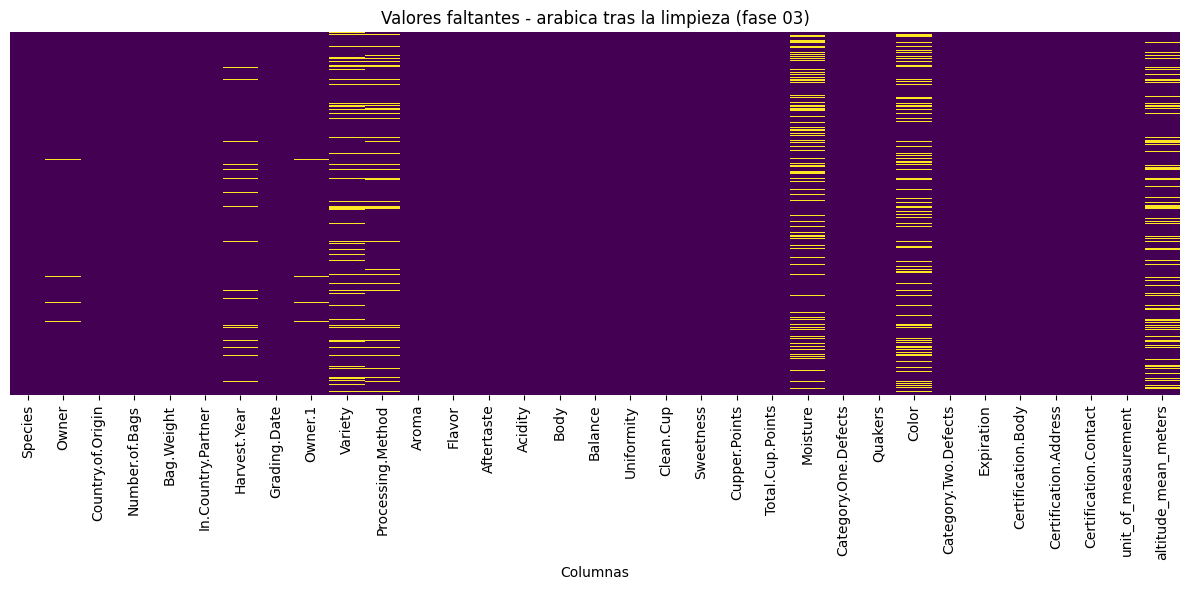

In [113]:
# Mapa de calor de los valores faltantes tras la limpieza (solo arabica)
import matplotlib.pyplot as plt
from src.visualization.plots import plot_missing_matrix

plot_missing_matrix(df, config, "nulos_arabica_limpio.png",
                    title="Valores faltantes - arabica tras la limpieza (fase 03)")
plt.show()

In [114]:
# ¿El registro con Quakers nulo es el mismo que el de Country.of.Origin nulo?
fila_quakers = df.index[df["Quakers"].isna()].tolist()
fila_pais    = df.index[df["Country.of.Origin"].isna()].tolist()
print("Fila(s) con Quakers nulo          :", fila_quakers)
print("Fila(s) con Country.of.Origin nulo:", fila_pais)

Fila(s) con Quakers nulo          : [366]
Fila(s) con Country.of.Origin nulo: [1197]


## 3.6 [PENDIENTE] Construcción de la matriz de entrada del clustering

> ⚠️ **Pendiente.** Se completa cuando se decida **qué subpuntajes entran** (`config.yaml -> clustering.features`): los 10, o sin `Uniformity` / `Clean.Cup` / `Sweetness` (casi constantes en 10, ver fase 02).

Lo que irá aquí:
- Seleccionar del dataset solo las columnas de `clustering.features`.
- Imputar los nulos que queden en esas columnas (no debería haber en arabica, pero se verifica).
- **Estandarizar** con `StandardScaler` (media 0, desviación 1) — imprescindible porque el clustering usa distancias (ver 3.2).
- Guardar el `StandardScaler` ajustado (para poder interpretar los centros de los grupos en unidades originales en la fase 06).
- Dejar preparada, opcionalmente, una versión reducida con **PCA** para comparar en la fase 04.

## 3.7 [PENDIENTE] Imputación final y dataset limpio completo

> ⚠️ **Pendiente.**

Lo que irá aquí:
- Imputar `altitude_mean_meters` con la **mediana**.
- Imputar las categóricas de perfilado (`Variety`, `Processing.Method`, `Color`) como `"Desconocido"`.
- Resolver el único lote con `Country.of.Origin` nulo.
- Construir `coffee_clean.csv`: subpuntajes SCA + variables de perfilado + `Total.Cup.Points` (referencia), sin columnas administrativas sobrantes.

## 3.8 [PENDIENTE] Verificación y guardado de artefactos

> ⚠️ **Pendiente.**

Lo que irá aquí:
- Comprobar: 0 nulos en la matriz de clustering, tipos correctos, shape esperado.
- Guardar en `data/processed/`: `clustering_input.csv` (matriz estandarizada) y `coffee_clean.csv` (dataset limpio completo).
- Mover la lógica ya validada de este notebook a `src/` (`data/clean_data.py`, `features/build_features.py`, `pipeline.prepare_data()`), y dejar el notebook llamando a la fachada.

## 3.9 [PENDIENTE] Hallazgos de la fase 03

> ⚠️ **Pendiente.** Resumen de: cuántas filas/columnas se eliminaron, decisión de especie, lista final de variables de clustering, y cómo queda el dataset para la fase 04.